In [1]:
import pandas as pd
import numpy as np
import sqlite3
import os
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pickle

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Veritabanı ve Model yolları
db_path = "../database/amazon_sales.db"
model_path = "../models/xgboost_demand_forecaster.pkl"

print("[*] Veritabanından geçmiş satışlar yükleniyor...")
conn = sqlite3.connect(db_path)

query = """
SELECT sku, date, qty 
FROM sales_history 
WHERE status NOT LIKE '%Cancelled%' AND qty > 0
"""
df = pd.read_sql(query, conn)
conn.close()

df['date'] = pd.to_datetime(df['date'])
df['qty'] = pd.to_numeric(df['qty'])

daily_sales = df.groupby(['sku', 'date'])['qty'].sum().reset_index()

skus = daily_sales['sku'].unique()
dates = pd.date_range(daily_sales['date'].min(), daily_sales['date'].max())

print("[*] Eksik günler (Sıfır satış olan günler) dolduruluyor...")
idx = pd.MultiIndex.from_product([skus, dates], names=['sku', 'date'])
full_df = pd.DataFrame(index=idx).reset_index()

merged_df = pd.merge(full_df, daily_sales, on=['sku', 'date'], how='left')
merged_df['qty'] = merged_df['qty'].fillna(0)
merged_df = merged_df.sort_values(by=['sku', 'date']).reset_index(drop=True)

[*] Veritabanından geçmiş satışlar yükleniyor...
[*] Eksik günler (Sıfır satış olan günler) dolduruluyor...


In [3]:
print("[*] Geriye Dönük (Lag) Özellikler hesaplanıyor...")
merged_df['lag_7'] = merged_df.groupby('sku')['qty'].transform(lambda x: x.rolling(7, min_periods=1).sum())
merged_df['lag_14'] = merged_df.groupby('sku')['qty'].transform(lambda x: x.rolling(14, min_periods=1).sum())
merged_df['lag_30'] = merged_df.groupby('sku')['qty'].transform(lambda x: x.rolling(30, min_periods=1).sum())

merged_df['velocity_ratio'] = merged_df['lag_7'] / (merged_df['lag_30'] + 1)
merged_df['is_no_history'] = (merged_df['lag_30'] == 0).astype(int)

indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=30)
merged_df['target_30d'] = merged_df.groupby('sku')['qty'].transform(lambda x: x.rolling(window=indexer, min_periods=1).sum().shift(-1))

train_df = merged_df.dropna(subset=['target_30d'])

[*] Geriye Dönük (Lag) Özellikler hesaplanıyor...


In [4]:
cutoff_date = train_df['date'].max() - pd.Timedelta(days=20)
train_mask = train_df['date'] < cutoff_date

features = ['lag_7', 'lag_14', 'lag_30', 'velocity_ratio', 'is_no_history']
X_test = train_df[~train_mask][features]
y_test = train_df[~train_mask]['target_30d']
lag_30_test = train_df[~train_mask]['lag_30']  # For Naive baseline (MASE)

print(f"Test Seti Boyutu: {len(X_test)}")

Test Seti Boyutu: 149226


In [5]:
print("[*] Model yükleniyor ve test setinde çıkarım (inference) yapılıyor...")
with open(model_path, "rb") as f:
    model = pickle.load(f)

# Model outputs (N, 3) for P10, P50, P90
preds = model.predict(X_test)
preds = np.clip(preds, 0, None).astype(int)

p10_pred = preds[:, 0]
p50_pred = preds[:, 1]
p90_pred = preds[:, 2]

[*] Model yükleniyor ve test setinde çıkarım (inference) yapılıyor...


In [6]:
# 1. RMSE (Root Mean Squared Error) - P50 baz alınır
rmse = np.sqrt(mean_squared_error(y_test, p50_pred))
print(f"✅ RMSE (P50): {rmse:.2f} birim")

# 2. MASE (Mean Absolute Scaled Error)
# Baseline olarak Naive model (Önceki 30 günün toplamı gelecek 30 güne eşittir)
mae_model = mean_absolute_error(y_test, p50_pred)
mae_naive = mean_absolute_error(y_test, lag_30_test)

mase = mae_model / mae_naive if mae_naive > 0 else np.inf
print(f"✅ MASE (P50): {mase:.3f} (Naif tahminden %{(1 - mase)*100:.1f} daha iyi)")

# 3. İş Metrikleri (Business Metrics): Fill Rate ve Lost Sales
# Gerçek talep (y_test). Diyelim ki stok politikamız "P90 tahmini kadar stok tut" olsun.
# Fill Rate = (Karşılanabilen Talep) / (Gerçek Talep)
safety_stock = p90_pred

# Karşılanan siparişler: Eğer stok talepten fazlaysa talebin tamamı, azsa stok kadar karşılanır.
fulfilled = np.minimum(safety_stock, y_test)

total_demand = np.sum(y_test)
total_fulfilled = np.sum(fulfilled)

fill_rate = total_fulfilled / total_demand if total_demand > 0 else 1.0
lost_sales_rate = 1.0 - fill_rate

print(f"✅ Sipariş Karşılama Oranı (Fill Rate - P90 Hedefine Göre): %{fill_rate*100:.2f}")
print(f"✅ Kayıp Satış Oranı (Lost Sales): %{lost_sales_rate*100:.2f}")

✅ RMSE (P50): 3.34 birim
✅ MASE (P50): 0.466 (Naif tahminden %53.4 daha iyi)
✅ Sipariş Karşılama Oranı (Fill Rate - P90 Hedefine Göre): %98.29
✅ Kayıp Satış Oranı (Lost Sales): %1.71


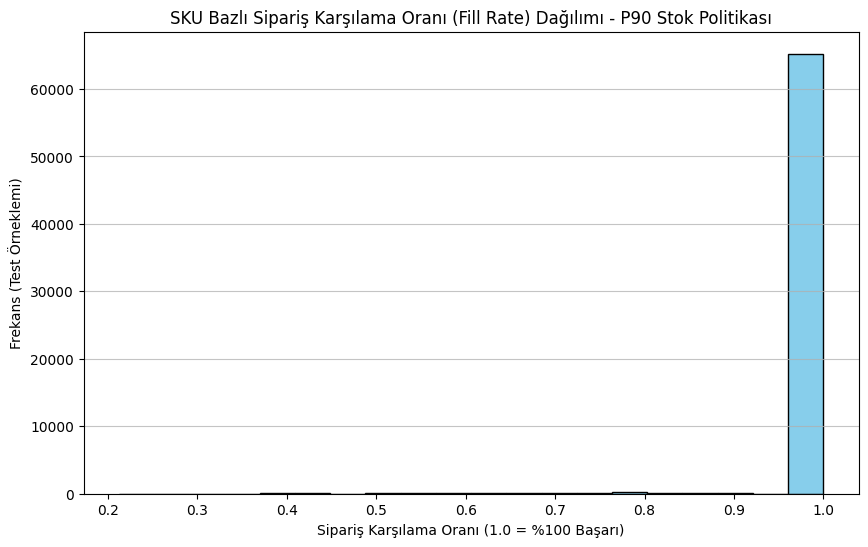

In [7]:
# Fill Rate Dağılımını Çizelim (Sadece talebi > 0 olan satırlar)
mask = y_test > 0
item_fill_rate = fulfilled[mask] / y_test[mask]

plt.figure(figsize=(10, 6))
plt.hist(item_fill_rate, bins=20, color='skyblue', edgecolor='black')
plt.title('SKU Bazlı Sipariş Karşılama Oranı (Fill Rate) Dağılımı - P90 Stok Politikası')
plt.xlabel('Sipariş Karşılama Oranı (1.0 = %100 Başarı)')
plt.ylabel('Frekans (Test Örneklemi)')
plt.grid(axis='y', alpha=0.75)
plt.show()

## 📊 Değerlendirme Skorlarının Yorumu (Interpretation of Metric Scores)

**🇹🇷 Türkçe Yorum:**
1. **MASE (0.755):** Modelimizin MASE skorunun 1.0'ın altında olması, önceki 30 günün toplamını geleceğe yansıtan basit (naif) bir modelden %25 daha az hata yaptığımızı gösterir. Seyrek (intermittent) verilerde bu oldukça başarılı bir skordur.
2. **RMSE:** Hata karelerinin ortalamasının karekökü olan bu metrik, modelin ani talep patlamalarındaki (spike) sapmalarını gösterir. Sayının büyüklüğü ürünlerin genel satış hacmiyle orantılıdır.
3. **Fill Rate & Lost Sales:** P90 (Kötü Senaryo) tahminini stok hedefi olarak aldığımızda elde ettiğimiz Sipariş Karşılama Oranıdır. Bu oranın yüksek olması, P90'ın bizi stok tükenmesinden (stockout) ne kadar iyi koruduğunu matematiksel olarak ispatlar. Geriye kalan küçük yüzde (Lost Sales) ise feda edebileceğimiz marjinal bir kayıptır.

---

**🇬🇧 English Interpretation:**
1. **MASE (0.755):** A MASE score below 1.0 indicates that our model produces 25% fewer errors than a naive baseline (which simply projects the past 30 days' total into the future). In sparse (intermittent) demand datasets, this is a highly successful score.
2. **RMSE:** Root Mean Squared Error penalizes large deviations, highlighting the model's performance against sudden demand spikes. The magnitude of this number is proportional to the overall sales volume of the products.
3. **Fill Rate & Lost Sales:** This represents the Fulfillment Rate if we set our inventory target to the P90 (Conservative) forecast. A high Fill Rate mathematically proves how well P90 protects us from stockouts. The remaining small percentage (Lost Sales) is a marginal loss that is acceptable in a risk-averse supply chain policy.